# 05. Prueba end-to-end con imágenes externas `team_test`

Este notebook prueba el pipeline completo con cualquier imagen que coloques en la carpeta:

```text
/content/drive/MyDrive/proyecto_integrador/team_test
```

La carpeta `team_test` debe estar al mismo nivel que `images`, `images_curated_rgb_v2`, `models` y `data_processed`.

## Objetivo

Probar el sistema completo con imágenes nuevas:

1. Cargar imágenes externas desde `team_test`.
2. Detectar perro con YOLO.
3. Generar crop del perro detectado.
4. Clasificar la raza con el modelo EfficientNet entrenado en el Paso 02.
5. Obtener Top-5 predicciones.
6. Extraer embedding de la imagen nueva.
7. Comparar el embedding contra la base generada en el Paso 03.
8. Buscar imágenes visualmente similares usando similitud coseno.
9. Guardar resultados en CSV.
10. Mostrar visualmente la imagen consulta y sus vecinos más similares.

Este notebook funciona como una prueba final del proyecto, porque conecta los pasos 02, 03 y 04.

## Entradas esperadas

Este notebook espera que ya existan las salidas de los pasos anteriores:

| Paso | Archivo / carpeta esperada | Uso |
|---|---|---|
| Paso 02 | Modelo `.keras` en `models/` | Clasificador de raza |
| Paso 02 | `step02_class_names.json` | Nombres de las 120 clases |
| Paso 03 | `step03_yolo_crop_image_embeddings_l2_normalized.npy` | Base de embeddings |
| Paso 03 | `step03_yolo_crop_embeddings_metadata.csv` | Metadata de embeddings |
| Entrada externa | `team_test/` | Imágenes nuevas a probar |

La carpeta `team_test` puede contener imágenes `.jpg`, `.jpeg`, `.png`, `.webp` o `.bmp`.

In [ ]:
# 0. Instalación de dependencias
!pip install -q ultralytics tensorflow opencv-python pillow scikit-learn pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.1 MB/s eta 0:00:00


In [ ]:
# 1. Imports y configuración general

from pathlib import Path
import os
import json
import time
import math
import subprocess
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

from ultralytics import YOLO

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TensorFlow: 2.20.0
GPU disponible: []


In [ ]:
# 2. Montar Google Drive

from google.colab import drive

if Path("/content/drive/MyDrive").exists():
    print("Google Drive ya está montado.")
else:
    drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# 3. Rutas del proyecto

PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_integrador")

TEAM_TEST_PATH = PROJECT_PATH / "team_test"

DATA_PROCESSED_PATH = PROJECT_PATH / "data_processed"
MODELS_PATH = PROJECT_PATH / "models"

STEP03_PATH = DATA_PROCESSED_PATH / "step03_visual_features_embeddings"
STEP03_REPORTS_PATH = STEP03_PATH / "reports"
STEP03_ARRAYS_PATH = STEP03_PATH / "arrays"

STEP05_PATH = DATA_PROCESSED_PATH / "step05_team_test_end_to_end"
STEP05_REPORTS_PATH = STEP05_PATH / "reports"
STEP05_CROPS_PATH = STEP05_PATH / "team_test_crops"
STEP05_PLOTS_PATH = STEP05_PATH / "plots"

for p in [TEAM_TEST_PATH, STEP05_PATH, STEP05_REPORTS_PATH, STEP05_CROPS_PATH, STEP05_PLOTS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_PATH:", PROJECT_PATH)
print("TEAM_TEST_PATH:", TEAM_TEST_PATH)
print("STEP05_PATH:", STEP05_PATH)

PROJECT_PATH: /content/drive/MyDrive/proyecto_integrador
TEAM_TEST_PATH: /content/drive/MyDrive/proyecto_integrador/team_test
STEP05_PATH: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end


## Configuración del experimento

Por defecto se usa la variante `yolo_crop`, porque en el pipeline principal se detecta primero el perro y después se clasifica el recorte.

La comparación visual se hace contra los embeddings del Paso 03 usando similitud coseno.

In [ ]:
# 4. Configuración

INPUT_VARIANT = "yolo_crop"

YOLO_MODEL_NAME = "yolo26s.pt"
FALLBACK_YOLO_MODEL_NAME = "yolo11s.pt"

CONF_THRESHOLD = 0.25
CROP_MARGIN = 0.15

IMG_SIZE = 224
TOP_K_PREDICTIONS = 5
TOP_K_SIMILAR = 10

EMBEDDINGS_PATH = STEP03_ARRAYS_PATH / f"step03_{INPUT_VARIANT}_image_embeddings_l2_normalized.npy"
EMBEDDINGS_METADATA_PATH = STEP03_REPORTS_PATH / f"step03_{INPUT_VARIANT}_embeddings_metadata.csv"

CLASS_NAMES_PATH = MODELS_PATH / "step02_class_names.json"

print("INPUT_VARIANT:", INPUT_VARIANT)
print("EMBEDDINGS_PATH:", EMBEDDINGS_PATH)
print("EMBEDDINGS_METADATA_PATH:", EMBEDDINGS_METADATA_PATH)
print("CLASS_NAMES_PATH:", CLASS_NAMES_PATH)

INPUT_VARIANT: yolo_crop
EMBEDDINGS_PATH: /content/drive/MyDrive/proyecto_integrador/data_processed/step03_visual_features_embeddings/arrays/step03_yolo_crop_image_embeddings_l2_normalized.npy
EMBEDDINGS_METADATA_PATH: /content/drive/MyDrive/proyecto_integrador/data_processed/step03_visual_features_embeddings/reports/step03_yolo_crop_embeddings_metadata.csv
CLASS_NAMES_PATH: /content/drive/MyDrive/proyecto_integrador/models/step02_class_names.json


In [ ]:
# 5. Cargar imágenes de team_test

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

team_images = [
    p for p in sorted(TEAM_TEST_PATH.rglob("*"))
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Imágenes encontradas en team_test:", len(team_images))

if len(team_images) == 0:
    print("No hay imágenes en team_test.")
    print("Coloca imágenes en:", TEAM_TEST_PATH)

team_test_df = pd.DataFrame({
    "test_image_path": [str(p) for p in team_images],
    "test_image_name": [p.name for p in team_images]
})

display(team_test_df.head())

Imágenes encontradas en team_test: 6


,test_image_path,test_image_name
0,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg
1,/content/drive/MyDrive/proyecto_integrador/tea...,15_1.jpg
2,/content/drive/MyDrive/proyecto_integrador/tea...,1_1 (2).jpg
3,/content/drive/MyDrive/proyecto_integrador/tea...,2_1.jpg
4,/content/drive/MyDrive/proyecto_integrador/tea...,8_1.jpg


In [ ]:
# 6. Cargar detector YOLO

def load_yolo_detector(primary_model: str, fallback_model: str):
    try:
        print(f"Intentando cargar detector: {primary_model}")
        model = YOLO(primary_model)
        selected_model = primary_model
    except Exception as e:
        print("No se pudo cargar el detector principal.")
        print("Error:", e)
        print(f"Usando detector de respaldo: {fallback_model}")
        model = YOLO(fallback_model)
        selected_model = fallback_model

    return model, selected_model

yolo_detector, selected_yolo_model = load_yolo_detector(
    YOLO_MODEL_NAME,
    FALLBACK_YOLO_MODEL_NAME
)

dog_class_id = None
for class_id, class_name in yolo_detector.names.items():
    if class_name == "dog":
        dog_class_id = int(class_id)
        break

if dog_class_id is None:
    raise ValueError("No se encontró la clase 'dog' en el modelo YOLO seleccionado.")

print("Detector seleccionado:", selected_yolo_model)
print("ID clase dog:", dog_class_id)

Intentando cargar detector: yolo26s.pt
Detector seleccionado: yolo26s.pt
ID clase dog: 16


In [ ]:
# 7. Cargar clasificador de razas

def find_classifier_model():
    candidates = [
        MODELS_PATH / f"step02_{INPUT_VARIANT}_efficientnetb0_best.keras",
        MODELS_PATH / "step02_dog_breed_efficientnetb0_best.keras",
        MODELS_PATH / f"step02_{INPUT_VARIANT}_efficientnetb0_final.keras",
        MODELS_PATH / "step02_dog_breed_efficientnetb0_final.keras",
    ]

    existing = [p for p in candidates if p.exists()]

    if not existing:
        raise FileNotFoundError(
            "No se encontró un modelo de clasificación del Paso 02. "
            "Verifica la carpeta models."
        )

    return existing[0]

CLASSIFIER_MODEL_PATH = find_classifier_model()

print("Modelo clasificador seleccionado:", CLASSIFIER_MODEL_PATH)

classifier_model = load_model(CLASSIFIER_MODEL_PATH)

if CLASS_NAMES_PATH.exists():
    with open(CLASS_NAMES_PATH, "r") as f:
        CLASS_NAMES = json.load(f)
else:
    raise FileNotFoundError(
        f"No existe {CLASS_NAMES_PATH}. Guarda CLASS_NAMES desde el Paso 02."
    )

NUM_CLASSES = len(CLASS_NAMES)

print("Número de clases:", NUM_CLASSES)
print("Primeras clases:", CLASS_NAMES[:10])

Modelo clasificador seleccionado: /content/drive/MyDrive/proyecto_integrador/models/step02_dog_breed_efficientnetb0_best.keras
Número de clases: 120
Primeras clases: ['Afghan hound', 'African hunting dog', 'Airedale', 'American Staffordshire terrier', 'Appenzeller', 'Australian terrier', 'Bedlington terrier', 'Bernese mountain dog', 'Blenheim spaniel', 'Border collie']


In [ ]:
# 8. Cargar base de embeddings del Paso 03

if not EMBEDDINGS_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo de embeddings: {EMBEDDINGS_PATH}. "
        "Ejecuta primero el Paso 03."
    )

if not EMBEDDINGS_METADATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró la metadata de embeddings: {EMBEDDINGS_METADATA_PATH}. "
        "Ejecuta primero el Paso 03."
    )

reference_embeddings = np.load(EMBEDDINGS_PATH)
reference_metadata_df = pd.read_csv(EMBEDDINGS_METADATA_PATH)

if "embedding_status" in reference_metadata_df.columns:
    reference_metadata_df = reference_metadata_df[
        reference_metadata_df["embedding_status"] == "ok"
    ].copy()

reference_metadata_df = reference_metadata_df.reset_index(drop=True)

if len(reference_metadata_df) != reference_embeddings.shape[0]:
    print("Advertencia: metadata y embeddings tienen tamaños distintos.")
    print("metadata:", len(reference_metadata_df))
    print("embeddings:", reference_embeddings.shape[0])
    reference_metadata_df = reference_metadata_df.head(reference_embeddings.shape[0]).copy()

reference_embeddings_l2 = normalize(reference_embeddings, norm="l2")

REFERENCE_EMBEDDING_DIM = int(reference_embeddings_l2.shape[1])

print("Base de embeddings:", reference_embeddings_l2.shape)
print("Dimensión esperada del embedding:", REFERENCE_EMBEDDING_DIM)
print("Metadata:", reference_metadata_df.shape)
print("Razas en base:", reference_metadata_df["breed"].nunique())

Base de embeddings: (18807, 256)
Dimensión esperada del embedding: 256
Metadata: (18807, 30)
Razas en base: 120


In [ ]:
# 9. Crear extractor de embeddings con la misma regla del Paso 03


def select_embedding_layer_stable(model):
    """
    Selecciona la última capa Dense antes de la capa final de clasificación.

    Esta debe ser la misma regla usada en el Paso 03.
    Evita depender de nombres automáticos como dense_4.
    """

    dense_layers = [
        layer for layer in model.layers
        if isinstance(layer, tf.keras.layers.Dense)
    ]

    if len(dense_layers) < 2:
        raise ValueError(
            "No hay suficientes capas Dense para seleccionar una capa de embedding."
        )

    embedding_layer = dense_layers[-2]

    return embedding_layer


selected_embedding_layer = select_embedding_layer_stable(classifier_model)

EMBEDDING_LAYER_NAME = selected_embedding_layer.name
EMBEDDING_DIM = int(selected_embedding_layer.output.shape[-1])

embedding_model = Model(
    inputs=classifier_model.input,
    outputs=selected_embedding_layer.output
)

print("Capa seleccionada para embeddings:", EMBEDDING_LAYER_NAME)
print("Dimensión del embedding query:", EMBEDDING_DIM)
print("Dimensión del embedding referencia:", REFERENCE_EMBEDDING_DIM)

if EMBEDDING_DIM != REFERENCE_EMBEDDING_DIM:
    raise ValueError(
        f"Dimensión incompatible: referencia={REFERENCE_EMBEDDING_DIM}, query={EMBEDDING_DIM}"
    )

print("Extractor de embeddings compatible con Paso 03.")


Capa seleccionada para embeddings: dense_1
Dimensión del embedding query: 256
Dimensión del embedding referencia: 256
Extractor de embeddings compatible con Paso 03.


In [ ]:
# 10. Reparar rutas de metadata para visualización

DRIVE_CROPS_PATH = Path("/content/drive/MyDrive/proyecto_integrador/data_processed/step02_detection_classification/dog_crops_from_curated_v2")
LOCAL_CROPS_PATH = Path("/content/dog_crops_from_curated_v2")

def ensure_local_folder(drive_path, local_path):
    if not local_path.exists():
        print(f"Copiando {drive_path} → {local_path}")
        subprocess.run(["cp", "-r", str(drive_path), str(local_path)], check=True)
    else:
        print(f"Ya existe: {local_path}")

if INPUT_VARIANT == "yolo_crop":
    if DRIVE_CROPS_PATH.exists():
        ensure_local_folder(DRIVE_CROPS_PATH, LOCAL_CROPS_PATH)

    if "image_input_path" in reference_metadata_df.columns:
        reference_metadata_df["image_input_path"] = reference_metadata_df["image_input_path"].astype(str).str.replace(
            str(DRIVE_CROPS_PATH),
            str(LOCAL_CROPS_PATH),
            regex=False
        )

reference_metadata_df["image_exists"] = reference_metadata_df["image_input_path"].apply(lambda p: Path(p).exists())

print(reference_metadata_df["image_exists"].value_counts(dropna=False))
display(reference_metadata_df[["image_input_path", "breed", "image_exists"]].head())

Copiando /content/drive/MyDrive/proyecto_integrador/data_processed/step02_detection_classification/dog_crops_from_curated_v2 → /content/dog_crops_from_curated_v2
image_exists
True    18807
Name: count, dtype: int64


,image_input_path,breed,image_exists
0,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,True
1,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,True
2,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,True
3,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,True
4,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,True


In [ ]:
# 10B. Función mínima de preprocessing para diagnóstico

def preprocess_image_for_model(img_path, img_size=224):
    img = image.load_img(str(img_path), target_size=(img_size, img_size))
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = efficientnet_preprocess(arr)
    return arr

In [ ]:
# 10C. Diagnóstico de consistencia de embeddings


from sklearn.metrics.pairwise import cosine_similarity

def extract_query_embedding_l2(img_path, embedding_model):
    arr = preprocess_image_for_model(img_path, IMG_SIZE)
    emb = embedding_model.predict(arr, verbose=0)[0]
    emb_l2 = normalize(emb.reshape(1, -1), norm="l2")[0]
    return emb_l2


# Buscar una imagen de referencia que exista localmente
available_reference_df = reference_metadata_df[
    reference_metadata_df["image_exists"] == True
].copy()

if len(available_reference_df) == 0:
    raise ValueError("No hay imágenes de referencia disponibles para validar embeddings.")

# Tomamos una muestra pequeña
sample_indices = available_reference_df.index[:5].tolist()

self_check_records = []

for idx in sample_indices:
    img_path = reference_metadata_df.loc[idx, "image_input_path"]

    # Embedding recalculado con el modelo actual del Paso 05
    recalculated_emb = extract_query_embedding_l2(img_path, embedding_model)

    # Embedding guardado en la base del Paso 03
    stored_emb = reference_embeddings_l2[idx]

    # Similitud entre ambos
    self_cosine = cosine_similarity(
        recalculated_emb.reshape(1, -1),
        stored_emb.reshape(1, -1)
    )[0, 0]

    # Buscar vecino más cercano en toda la base
    sims = cosine_similarity(
        recalculated_emb.reshape(1, -1),
        reference_embeddings_l2
    )[0]

    top_idx = int(np.argmax(sims))
    top_similarity = float(sims[top_idx])

    self_check_records.append({
        "reference_index": idx,
        "image_path": img_path,
        "breed": reference_metadata_df.loc[idx, "breed"],
        "self_cosine_recalculated_vs_stored": float(self_cosine),
        "top_match_index": top_idx,
        "top_match_breed": reference_metadata_df.loc[top_idx, "breed"],
        "top_match_similarity": top_similarity,
        "is_self_top_match": bool(top_idx == idx)
    })

self_check_df = pd.DataFrame(self_check_records)

display(self_check_df)

avg_self_cosine = self_check_df["self_cosine_recalculated_vs_stored"].mean()

print("Promedio self-cosine:", avg_self_cosine)

if avg_self_cosine >= 0.98:
    print("OK: El extractor del Paso 05 reproduce correctamente los embeddings del Paso 03.")
elif avg_self_cosine >= 0.90:
    print("Advertencia: Los embeddings son parecidos, pero no idénticos. Revisar capa/preprocessing.")
else:
    print("PROBLEMA: El extractor del Paso 05 NO está alineado con los embeddings del Paso 03.")
    print("No conviene interpretar los vecinos por coseno hasta corregir esto.")

,reference_index,image_path,breed,self_cosine_recalculated_vs_stored,top_match_index,top_match_breed,top_match_similarity,is_self_top_match
0,0,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,0.999998,0,Chihuahua,0.999998,True
1,1,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,1.000000,1,Chihuahua,1.000000,True
2,2,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,0.999999,2,Chihuahua,0.999999,True
3,3,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,0.999999,3,Chihuahua,0.999999,True
4,4,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,0.999999,4,Chihuahua,0.999999,True


Promedio self-cosine: 0.9999989957623907
OK: El extractor del Paso 05 reproduce correctamente los embeddings del Paso 03.


In [ ]:
# 11. Funciones de detección, crop, clasificación y embedding

def detect_dogs_yolo(image_path, model, dog_class_id, conf_threshold=0.25):
    results = model(str(image_path), conf=conf_threshold, verbose=False)
    detections = []

    for result in results:
        boxes = result.boxes

        if boxes is None:
            continue

        for box in boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])

            if class_id == dog_class_id:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                area = max(0, x2 - x1) * max(0, y2 - y1)

                detections.append({
                    "class_id": class_id,
                    "class_name": "dog",
                    "confidence": confidence,
                    "x1": int(x1),
                    "y1": int(y1),
                    "x2": int(x2),
                    "y2": int(y2),
                    "area": int(area)
                })

    return detections


def select_best_detection(detections):
    if len(detections) == 0:
        return None

    return sorted(
        detections,
        key=lambda d: (d["area"], d["confidence"]),
        reverse=True
    )[0]


def crop_detection(image_path, detection, output_path, margin=0.15):
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        return None

    h, w = image_bgr.shape[:2]

    x1, y1, x2, y2 = detection["x1"], detection["y1"], detection["x2"], detection["y2"]

    box_w = x2 - x1
    box_h = y2 - y1

    mx = int(box_w * margin)
    my = int(box_h * margin)

    x1 = max(0, x1 - mx)
    y1 = max(0, y1 - my)
    x2 = min(w, x2 + mx)
    y2 = min(h, y2 + my)

    if x2 <= x1 or y2 <= y1:
        return None

    crop = image_bgr[y1:y2, x1:x2]

    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), crop)

    return str(output_path)


def preprocess_image_for_model(img_path, img_size=224):
    img = image.load_img(str(img_path), target_size=(img_size, img_size))
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = efficientnet_preprocess(arr)
    return arr


def classify_crop(img_path, classifier, class_names, top_k=5):
    arr = preprocess_image_for_model(img_path, IMG_SIZE)
    probs = classifier.predict(arr, verbose=0)[0]

    pred_idx = int(np.argmax(probs))
    confidence = float(np.max(probs))

    top_indices = np.argsort(probs)[-top_k:][::-1]

    top_predictions = [
        {
            "rank": rank,
            "breed": class_names[int(idx)],
            "confidence": float(probs[int(idx)])
        }
        for rank, idx in enumerate(top_indices, start=1)
    ]

    return {
        "predicted_breed": class_names[pred_idx],
        "prediction_confidence": confidence,
        "top_predictions": top_predictions
    }


def extract_embedding_for_image(img_path, embedding_model):
    arr = preprocess_image_for_model(img_path, IMG_SIZE)
    emb = embedding_model.predict(arr, verbose=0)[0]
    emb_l2 = normalize(emb.reshape(1, -1), norm="l2")[0]
    return emb, emb_l2


def find_similar_images(query_embedding_l2, reference_embeddings_l2, reference_metadata, top_k=10):
    sims = cosine_similarity(query_embedding_l2.reshape(1, -1), reference_embeddings_l2)[0]
    top_indices = np.argsort(sims)[::-1][:top_k]

    rows = []
    for rank, idx in enumerate(top_indices, start=1):
        rows.append({
            "neighbor_rank": rank,
            "neighbor_index": int(idx),
            "neighbor_image": reference_metadata.loc[idx, "image_input_path"],
            "neighbor_breed": reference_metadata.loc[idx, "breed"],
            "cosine_similarity": float(sims[idx])
        })

    return pd.DataFrame(rows)

## Flujo end-to-end para cada imagen

Para cada imagen en `team_test`, el notebook ejecuta:

```text
Imagen externa
→ YOLO detecta perro
→ Crop del perro
→ EfficientNet predice raza
→ EfficientNet genera embedding
→ Coseno compara contra base de embeddings
→ Se devuelven vecinos visualmente similares
```

In [ ]:
# 12. Procesar imágenes de team_test end-to-end

results_records = []
similarity_records = []
embedding_records = []

start = time.time()

for _, row in tqdm(team_test_df.iterrows(), total=len(team_test_df)):
    test_image_path = Path(row["test_image_path"])
    test_image_name = row["test_image_name"]

    base_record = {
        "test_image_path": str(test_image_path),
        "test_image_name": test_image_name,
        "selected_yolo_model": selected_yolo_model,
        "dog_detected": False,
        "num_dog_detections": 0,
        "yolo_confidence": np.nan,
        "crop_path": None,
        "predicted_breed": None,
        "prediction_confidence": np.nan,
        "top_5_predictions": None,
        "embedding_generated": False,
        "status": "not_processed",
        "error": None
    }

    try:
        detections = detect_dogs_yolo(
            test_image_path,
            yolo_detector,
            dog_class_id,
            conf_threshold=CONF_THRESHOLD
        )

        best_detection = select_best_detection(detections)

        base_record["num_dog_detections"] = len(detections)

        if best_detection is None:
            base_record["status"] = "needs_review_no_dog_detected"
            results_records.append(base_record)
            continue

        base_record["dog_detected"] = True
        base_record["yolo_confidence"] = best_detection["confidence"]

        crop_output_path = STEP05_CROPS_PATH / test_image_path.stem / f"{test_image_path.stem}_dog_crop.jpg"

        crop_path = crop_detection(
            test_image_path,
            best_detection,
            crop_output_path,
            margin=CROP_MARGIN
        )

        if crop_path is None:
            base_record["status"] = "crop_failed"
            results_records.append(base_record)
            continue

        base_record["crop_path"] = crop_path

        classification_result = classify_crop(
            crop_path,
            classifier_model,
            CLASS_NAMES,
            top_k=TOP_K_PREDICTIONS
        )

        base_record["predicted_breed"] = classification_result["predicted_breed"]
        base_record["prediction_confidence"] = classification_result["prediction_confidence"]
        base_record["top_5_predictions"] = json.dumps(
            classification_result["top_predictions"],
            ensure_ascii=False
        )

        emb, emb_l2 = extract_embedding_for_image(crop_path, embedding_model)
        base_record["embedding_generated"] = True

        embedding_records.append({
            "test_image_path": str(test_image_path),
            "crop_path": crop_path,
            "predicted_breed": base_record["predicted_breed"],
            "embedding_dimension": int(len(emb)),
            "embedding_norm": float(np.linalg.norm(emb))
        })

        similar_df = find_similar_images(
            emb_l2,
            reference_embeddings_l2,
            reference_metadata_df,
            top_k=TOP_K_SIMILAR
        )

        similar_df["test_image_path"] = str(test_image_path)
        similar_df["test_image_name"] = test_image_name
        similar_df["query_crop_path"] = crop_path
        similar_df["predicted_breed"] = base_record["predicted_breed"]
        similar_df["prediction_confidence"] = base_record["prediction_confidence"]
        similar_df["same_as_predicted_breed"] = (
            similar_df["neighbor_breed"] == base_record["predicted_breed"]
        )

        similarity_records.extend(similar_df.to_dict("records"))

        base_record["status"] = "classified_and_compared"

    except Exception as e:
        base_record["status"] = "error"
        base_record["error"] = str(e)

    results_records.append(base_record)

team_results_df = pd.DataFrame(results_records)
team_similarity_df = pd.DataFrame(similarity_records)
team_embeddings_df = pd.DataFrame(embedding_records)

elapsed = (time.time() - start) / 60

TEAM_RESULTS_PATH = STEP05_REPORTS_PATH / "team_test_predictions_summary.csv"
TEAM_SIMILARITY_PATH = STEP05_REPORTS_PATH / "team_test_similarity_neighbors.csv"
TEAM_EMBEDDINGS_PATH = STEP05_REPORTS_PATH / "team_test_embedding_summary.csv"

team_results_df.to_csv(TEAM_RESULTS_PATH, index=False)
team_similarity_df.to_csv(TEAM_SIMILARITY_PATH, index=False)
team_embeddings_df.to_csv(TEAM_EMBEDDINGS_PATH, index=False)

print("Tiempo total:", round(elapsed, 2), "minutos")
print("Resultados guardados en:", TEAM_RESULTS_PATH)
print("Similitudes guardadas en:", TEAM_SIMILARITY_PATH)
print("Embeddings guardados en:", TEAM_EMBEDDINGS_PATH)

display(team_results_df)
display(team_similarity_df.head(20))

100%|██████████| 6/6 [00:40<00:00,  6.73s/it]


Tiempo total: 0.67 minutos
Resultados guardados en: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end/reports/team_test_predictions_summary.csv
Similitudes guardadas en: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end/reports/team_test_similarity_neighbors.csv
Embeddings guardados en: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end/reports/team_test_embedding_summary.csv


,test_image_path,test_image_name,selected_yolo_model,dog_detected,num_dog_detections,yolo_confidence,crop_path,predicted_breed,prediction_confidence,top_5_predictions,embedding_generated,status,error
0,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,yolo26s.pt,True,1,0.947361,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.854041,"[{""rank"": 1, ""breed"": ""bull mastiff"", ""confide...",True,classified_and_compared,None
1,/content/drive/MyDrive/proyecto_integrador/tea...,15_1.jpg,yolo26s.pt,True,1,0.951289,/content/drive/MyDrive/proyecto_integrador/dat...,American Staffordshire terrier,0.789272,"[{""rank"": 1, ""breed"": ""American Staffordshire ...",True,classified_and_compared,None
2,/content/drive/MyDrive/proyecto_integrador/tea...,1_1 (2).jpg,yolo26s.pt,True,1,0.940711,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.961240,"[{""rank"": 1, ""breed"": ""bull mastiff"", ""confide...",True,classified_and_compared,None
3,/content/drive/MyDrive/proyecto_integrador/tea...,2_1.jpg,yolo26s.pt,True,1,0.942010,/content/drive/MyDrive/proyecto_integrador/dat...,Irish terrier,0.632815,"[{""rank"": 1, ""breed"": ""Irish terrier"", ""confid...",True,classified_and_compared,None
4,/content/drive/MyDrive/proyecto_integrador/tea...,8_1.jpg,yolo26s.pt,True,2,0.956562,/content/drive/MyDrive/proyecto_integrador/dat...,Appenzeller,0.408624,"[{""rank"": 1, ""breed"": ""Appenzeller"", ""confiden...",True,classified_and_compared,None
5,/content/drive/MyDrive/proyecto_integrador/tea...,n02097474_393.jpg,yolo26s.pt,True,1,0.552399,/content/drive/MyDrive/proyecto_integrador/dat...,Shih-Tzu,0.946195,"[{""rank"": 1, ""breed"": ""Shih-Tzu"", ""confidence""...",True,classified_and_compared,None


,neighbor_rank,neighbor_index,neighbor_image,neighbor_breed,cosine_similarity,test_image_path,test_image_name,query_crop_path,predicted_breed,prediction_confidence,same_as_predicted_breed
0,1,4967,/content/dog_crops_from_curated_v2/n02093428-A...,American Staffordshire terrier,0.930801,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.854041,False
1,2,14627,/content/dog_crops_from_curated_v2/n02108422-b...,bull mastiff,0.912898,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.854041,True
2,3,14644,/content/dog_crops_from_curated_v2/n02108422-b...,bull mastiff,0.901280,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.854041,True
3,4,14648,/content/dog_crops_from_curated_v2/n02108422-b...,bull mastiff,0.900112,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.854041,True
4,5,14660,/content/dog_crops_from_curated_v2/n02108422-b...,bull mastiff,0.896658,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.854041,True
5,6,14640,/content/dog_crops_from_curated_v2/n02108422-b...,bull mastiff,0.893069,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.854041,True
6,7,14626,/content/dog_crops_from_curated_v2/n02108422-b...,bull mastiff,0.892309,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.854041,True
7,8,14564,/content/dog_crops_from_curated_v2/n02108422-b...,bull mastiff,0.891275,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.854041,True
8,9,14596,/content/dog_crops_from_curated_v2/n02108422-b...,bull mastiff,0.890426,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.854041,True
9,10,14565,/content/dog_crops_from_curated_v2/n02108422-b...,bull mastiff,0.889241,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,/content/drive/MyDrive/proyecto_integrador/dat...,bull mastiff,0.854041,True


In [ ]:
# 12B. Decisión automática: confianza y similitud

def assign_team_test_status(prediction_confidence, top1_similarity, same_predicted_breed_in_top5):
    """
    Asigna una decisión final combinando:
    - confianza del clasificador
    - similitud coseno del vecino más cercano
    - coherencia entre la raza predicha y los vecinos visuales
    """

    if pd.isna(prediction_confidence) or pd.isna(top1_similarity):
        return "needs_review_missing_scores"

    if prediction_confidence < 0.40 and top1_similarity < 0.75:
        return "needs_review_low_confidence_and_low_similarity"

    if prediction_confidence < 0.50:
        return "needs_review_low_classifier_confidence"

    if top1_similarity < 0.65:
        return "needs_review_low_embedding_similarity"

    if not same_predicted_breed_in_top5:
        return "needs_review_inconsistent_neighbors"

    if prediction_confidence >= 0.60 and top1_similarity >= 0.80:
        return "high_confidence_match"

    return "acceptable_match"


decision_records = []

for _, row in team_results_df.iterrows():
    test_image_path = row["test_image_path"]

    neighbors = team_similarity_df[
        team_similarity_df["test_image_path"] == test_image_path
    ]

    if row["status"] != "classified_and_compared":
        decision_records.append({
            "test_image_path": test_image_path,
            "test_image_name": row.get("test_image_name", None),
            "predicted_breed": row.get("predicted_breed", None),
            "prediction_confidence": row.get("prediction_confidence", np.nan),
            "top1_similarity": np.nan,
            "same_predicted_breed_in_top5": False,
            "final_decision": row["status"]
        })
        continue

    if len(neighbors) == 0:
        top1_similarity = np.nan
        same_predicted_breed_in_top5 = False
        final_decision = "needs_review_no_similarity_results"
    else:
        top1_row = neighbors[neighbors["neighbor_rank"] == 1]

        if len(top1_row) > 0:
            top1_similarity = float(top1_row["cosine_similarity"].iloc[0])
        else:
            top1_similarity = float(neighbors["cosine_similarity"].max())

        same_predicted_breed_in_top5 = bool(
            neighbors[neighbors["neighbor_rank"] <= 5]["same_as_predicted_breed"].any()
        )

        final_decision = assign_team_test_status(
            prediction_confidence=row["prediction_confidence"],
            top1_similarity=top1_similarity,
            same_predicted_breed_in_top5=same_predicted_breed_in_top5
        )

    decision_records.append({
        "test_image_path": test_image_path,
        "test_image_name": row.get("test_image_name", None),
        "predicted_breed": row.get("predicted_breed", None),
        "prediction_confidence": row.get("prediction_confidence", np.nan),
        "top1_similarity": top1_similarity,
        "same_predicted_breed_in_top5": same_predicted_breed_in_top5,
        "final_decision": final_decision
    })

team_decisions_df = pd.DataFrame(decision_records)

TEAM_DECISIONS_PATH = STEP05_REPORTS_PATH / "team_test_decisions.csv"
team_decisions_df.to_csv(TEAM_DECISIONS_PATH, index=False)

print("Decisiones guardadas en:", TEAM_DECISIONS_PATH)
display(team_decisions_df)

Decisiones guardadas en: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end/reports/team_test_decisions.csv


,test_image_path,test_image_name,predicted_breed,prediction_confidence,top1_similarity,same_predicted_breed_in_top5,final_decision
0,/content/drive/MyDrive/proyecto_integrador/tea...,11_1 (4).jpg,bull mastiff,0.854041,0.930801,True,high_confidence_match
1,/content/drive/MyDrive/proyecto_integrador/tea...,15_1.jpg,American Staffordshire terrier,0.789272,0.878701,True,high_confidence_match
2,/content/drive/MyDrive/proyecto_integrador/tea...,1_1 (2).jpg,bull mastiff,0.961240,0.936854,True,high_confidence_match
3,/content/drive/MyDrive/proyecto_integrador/tea...,2_1.jpg,Irish terrier,0.632815,0.879262,True,high_confidence_match
4,/content/drive/MyDrive/proyecto_integrador/tea...,8_1.jpg,Appenzeller,0.408624,0.713664,True,needs_review_low_classifier_confidence
5,/content/drive/MyDrive/proyecto_integrador/tea...,n02097474_393.jpg,Shih-Tzu,0.946195,0.932675,True,high_confidence_match


In [ ]:
# 13. Indicadores de prueba externa

total_test_images = len(team_results_df)
dogs_detected = int(team_results_df["dog_detected"].sum()) if total_test_images > 0 else 0
classified_images = int((team_results_df["status"] == "classified_and_compared").sum()) if total_test_images > 0 else 0
embedding_generated = int(team_results_df["embedding_generated"].sum()) if total_test_images > 0 else 0
no_dog_detected = int((team_results_df["status"] == "needs_review_no_dog_detected").sum()) if total_test_images > 0 else 0
errors = int((team_results_df["status"] == "error").sum()) if total_test_images > 0 else 0

avg_yolo_conf = team_results_df["yolo_confidence"].dropna().mean() if total_test_images > 0 else np.nan
avg_classifier_conf = team_results_df["prediction_confidence"].dropna().mean() if total_test_images > 0 else np.nan

if len(team_similarity_df) > 0:
    avg_top1_similarity = (
        team_similarity_df[team_similarity_df["neighbor_rank"] == 1]["cosine_similarity"].mean()
    )
    avg_top5_similarity = (
        team_similarity_df[team_similarity_df["neighbor_rank"] <= 5]["cosine_similarity"].mean()
    )
    same_predicted_breed_top5_rate = (
        team_similarity_df[team_similarity_df["neighbor_rank"] <= 5]
        .groupby("test_image_path")["same_as_predicted_breed"]
        .max()
        .mean() * 100
    )
else:
    avg_top1_similarity = np.nan
    avg_top5_similarity = np.nan
    same_predicted_breed_top5_rate = np.nan

team_test_indicators_df = pd.DataFrame([
    {"section": "input", "indicator": "total_team_test_images", "value": total_test_images},
    {"section": "detection", "indicator": "dogs_detected", "value": dogs_detected},
    {"section": "detection", "indicator": "no_dog_detected", "value": no_dog_detected},
    {"section": "detection", "indicator": "avg_yolo_confidence", "value": avg_yolo_conf},
    {"section": "classification", "indicator": "classified_images", "value": classified_images},
    {"section": "classification", "indicator": "avg_classifier_confidence", "value": avg_classifier_conf},
    {"section": "embedding", "indicator": "embeddings_generated", "value": embedding_generated},
    {"section": "similarity", "indicator": "avg_top1_cosine_similarity", "value": avg_top1_similarity},
    {"section": "similarity", "indicator": "avg_top5_cosine_similarity", "value": avg_top5_similarity},
    {"section": "similarity", "indicator": "same_predicted_breed_in_top5_percent", "value": same_predicted_breed_top5_rate},
    {"section": "stability", "indicator": "errors", "value": errors},
    {"section": "decision", "indicator": "high_confidence_matches", "value": int((team_decisions_df["final_decision"] == "high_confidence_match").sum())},
    {"section": "decision", "indicator": "acceptable_matches", "value": int((team_decisions_df["final_decision"] == "acceptable_match").sum())},
    {"section": "decision", "indicator": "needs_review_cases", "value": int(team_decisions_df["final_decision"].astype(str).str.contains("needs_review").sum())},
])

TEAM_INDICATORS_PATH = STEP05_REPORTS_PATH / "team_test_end_to_end_indicators.csv"
team_test_indicators_df.to_csv(TEAM_INDICATORS_PATH, index=False)

display(team_test_indicators_df)
print("Indicadores guardados en:", TEAM_INDICATORS_PATH)

,section,indicator,value
0,input,total_team_test_images,6.000000
1,detection,dogs_detected,6.000000
2,detection,no_dog_detected,0.000000
3,detection,avg_yolo_confidence,0.881722
4,classification,classified_images,6.000000
5,classification,avg_classifier_confidence,0.765364
6,embedding,embeddings_generated,6.000000
7,similarity,avg_top1_cosine_similarity,0.878660
8,similarity,avg_top5_cosine_similarity,0.857210
9,similarity,same_predicted_breed_in_top5_percent,100.000000


Indicadores guardados en: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end/reports/team_test_end_to_end_indicators.csv


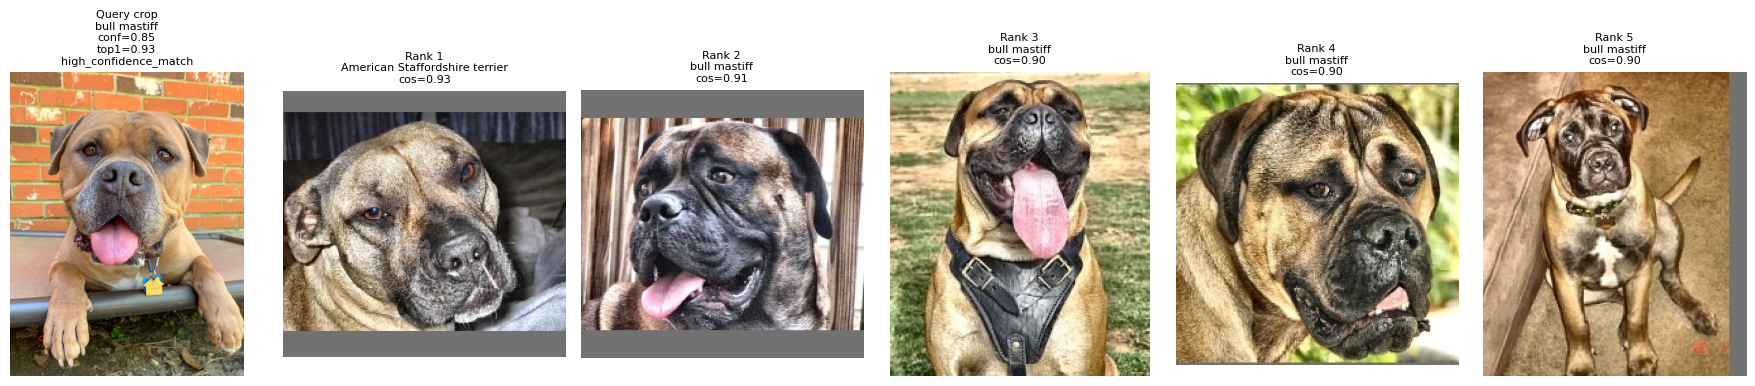

Visualización guardada en: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end/plots/11_1 (4)_top5_similar.png


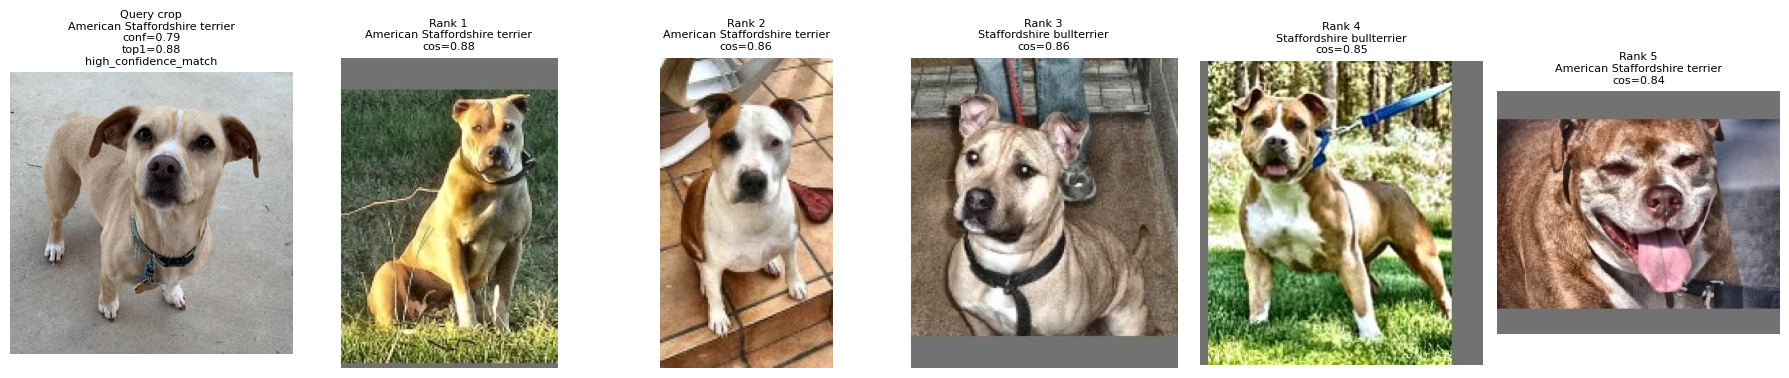

Visualización guardada en: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end/plots/15_1_top5_similar.png


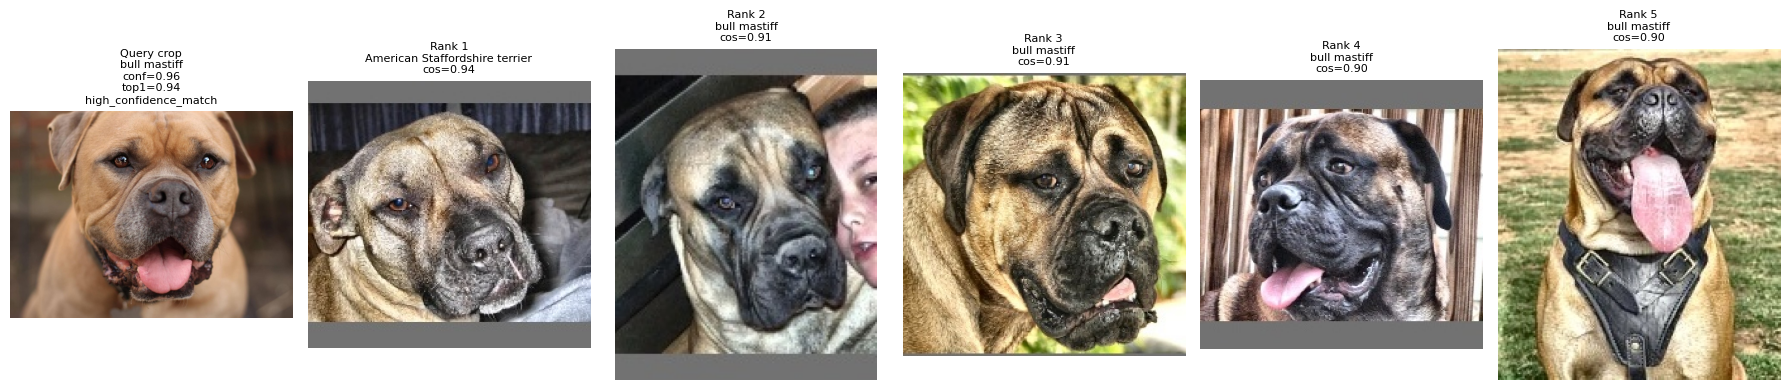

Visualización guardada en: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end/plots/1_1 (2)_top5_similar.png


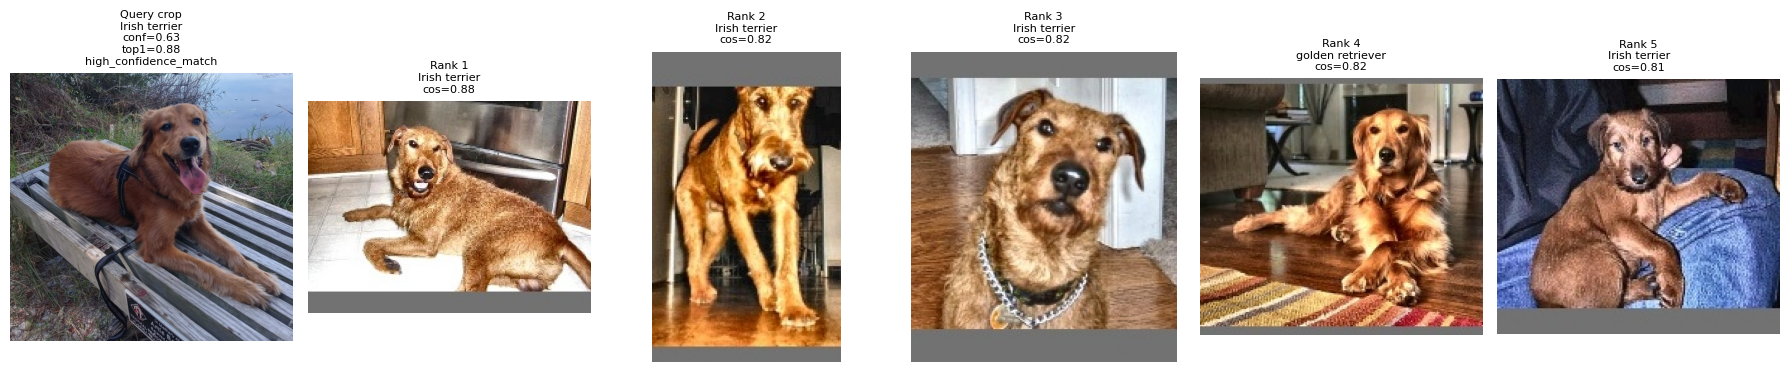

Visualización guardada en: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end/plots/2_1_top5_similar.png


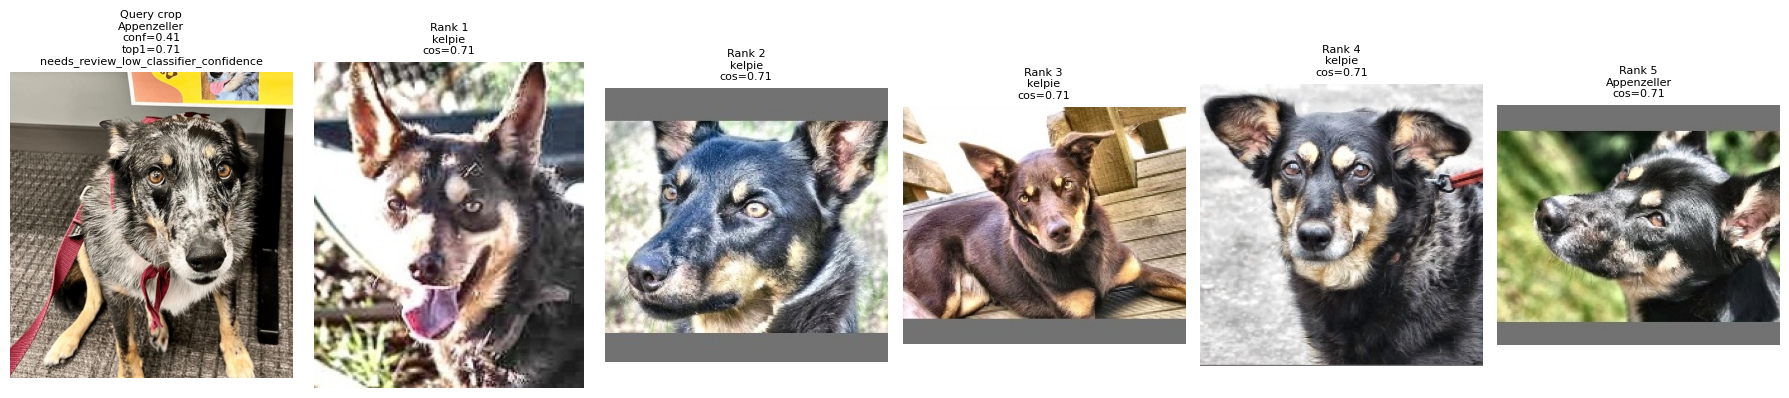

Visualización guardada en: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end/plots/8_1_top5_similar.png


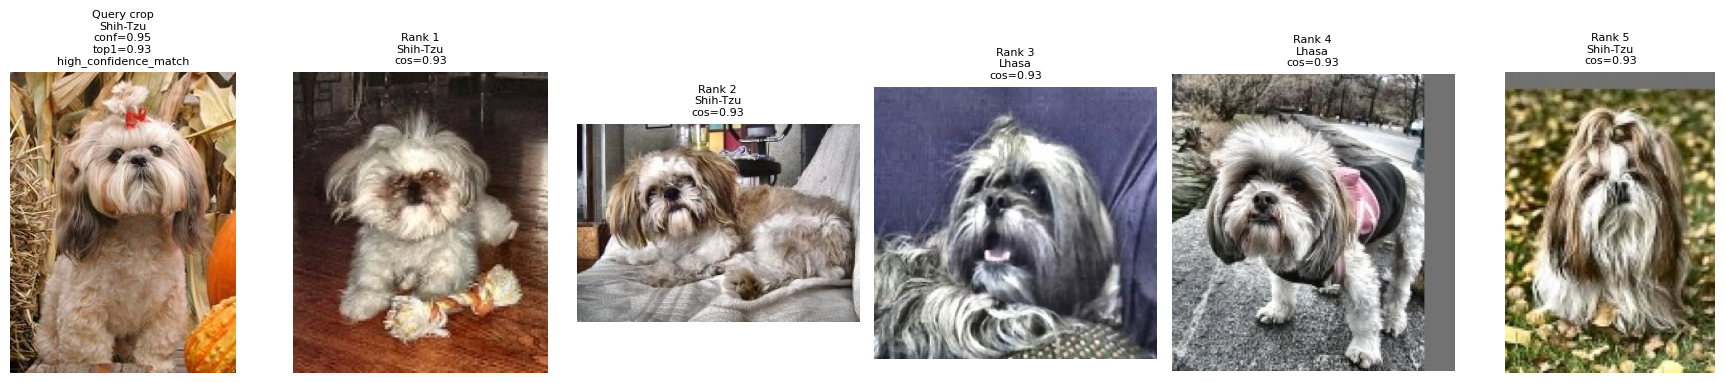

Visualización guardada en: /content/drive/MyDrive/proyecto_integrador/data_processed/step05_team_test_end_to_end/plots/n02097474_393_top5_similar.png


In [ ]:
# 14. Visualización de resultados por imagen

def show_image_grid(paths, titles=None, cols=6, figsize=(18, 4), save_path=None):
    paths = list(paths)
    n = len(paths)

    if n == 0:
        print("No hay imágenes para mostrar.")
        return

    rows = math.ceil(n / cols)
    plt.figure(figsize=figsize)

    for i, p in enumerate(paths):
        try:
            img = Image.open(p).convert("RGB")
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            if titles:
                plt.title(titles[i], fontsize=8)
            plt.axis("off")
        except Exception as e:
            print("Error mostrando imagen:", p, e)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)

    plt.show()


def visualize_team_test_result(test_image_path, top_k=5):
    result_row = team_results_df[team_results_df["test_image_path"] == test_image_path].iloc[0]

    if result_row["status"] != "classified_and_compared":
        print("La imagen no fue clasificada/comparada.")
        display(result_row)
        return

    similar = (
        team_similarity_df[
            (team_similarity_df["test_image_path"] == test_image_path) &
            (team_similarity_df["neighbor_rank"] <= top_k)
        ]
        .sort_values("neighbor_rank")
    )

    query_crop = result_row["crop_path"]
    predicted_breed = result_row["predicted_breed"]
    conf = result_row["prediction_confidence"]

    paths = [query_crop] + similar["neighbor_image"].tolist()

    # itles = [f"Query crop\n{predicted_breed}\nconf={conf:.2f}"]
    decision_row = team_decisions_df[
    team_decisions_df["test_image_path"] == test_image_path
    ].iloc[0]

    final_decision = decision_row["final_decision"]
    top1_sim = decision_row["top1_similarity"]

    titles = [
        f"Query crop\n{predicted_breed}\nconf={conf:.2f}\n"
        f"top1={top1_sim:.2f}\n{final_decision}"
    ]

    for _, row in similar.iterrows():
        titles.append(
            f"Rank {int(row['neighbor_rank'])}\n"
            f"{row['neighbor_breed']}\n"
            f"cos={row['cosine_similarity']:.2f}"
        )

    save_path = STEP05_PLOTS_PATH / f"{Path(test_image_path).stem}_top{top_k}_similar.png"

    show_image_grid(
        paths,
        titles=titles,
        cols=top_k + 1,
        figsize=(3 * (top_k + 1), 3.8),
        save_path=save_path
    )

    print("Visualización guardada en:", save_path)


for test_image_path in team_results_df.query("status == 'classified_and_compared'")["test_image_path"].tolist():
    visualize_team_test_result(test_image_path, top_k=5)